# ICePop tutorial

## 1. Extract metacells

In [19]:
! icepop metacell \
    --h5ad ../data/TM_FACS/TM_FACS_cnt.h5ad \
    --outdir ../results/TM_FACS \
    --save_name TM_FACS \
    --device cpu # or 'cuda' (default) to speed up the run

2026-04-24 20:36:35,907 - icepop.metacell - INFO - Max expression value: 31922356.0
2026-04-24 20:36:35,907 - icepop.metacell - INFO - Totol number of cells: 110824, target metacell number: 1478
2026-04-24 20:36:36,068 - icepop.metacell - INFO - Overall purity stats:
count    1433.000000
mean        0.832608
std         0.198578
min         0.159091
25%         0.706897
50%         0.931818
75%         0.988235
max         1.000000
Name: purity, dtype: float64


## 2. Get association, mixture and influence diagnoistics

In [20]:
! icepop association \
    --h5ad ../data/TM_FACS/TM_FACS_cnt.h5ad \
    --mc_assign ../results/TM_FACS/mc_assign.csv \
    --magmaz ../data/magmaz/PASS_UC_deLange2017.genes.out \
    --sp mmusculus \
    --outdir ../results/TM_FACS

2026-04-24 20:36:40,619 - icepop.association - INFO - Starting association analysis
2026-04-24 20:36:40,619 - icepop.association - INFO - Inputs: h5ad=../data/TM_FACS/TM_FACS_cnt.h5ad, mc_assign=../results/TM_FACS/mc_assign.csv, magmaz=../data/magmaz/PASS_UC_deLange2017.genes.out
2026-04-24 20:36:40,619 - icepop.association - INFO - Params: ct_key=cell_type, sp=mmusculus, n_perm=1000, q_thres=0.1, n_jobs=20
2026-04-24 20:36:40,619 - icepop.association - INFO - Loading h5ad and metacell assignment
2026-04-24 20:36:41,031 - icepop.association - INFO - Loaded adata: n_cells=110824, n_genes=22499
2026-04-24 20:36:41,031 - icepop.association - INFO - Number of cell_type: 120
2026-04-24 20:36:41,042 - icepop.association - INFO - Number of metacells 1433
2026-04-24 20:36:41,047 - icepop.association - INFO - Metacell sizes: min=1, median=75.0, max=12613
2026-04-24 20:36:41,972 - icepop.association - INFO - Loading precomputed metacell specificity scores
2026-04-24 20:36:42,131 - icepop.associa

## 3.Enrichment analysis and interactive output

In [21]:
# run all gene sets
! icepop interactive \
  --outdir ../results/TM_FACS \
  --mcdir ../results/TM_FACS \
  --geneset_collections All \
  --adata_path ../data/TM_FACS/TM_FACS_cnt.h5ad

2026-04-24 20:40:48,778 - icepop.interactive - INFO - Enrichment output directory: ../results/TM_FACS
2026-04-24 20:40:48,778 - icepop.interactive - INFO - Starting enrichment analysis...
2026-04-24 20:41:16,209 - icepop.interactive - INFO - Enrichment completed in 27.43 seconds
2026-04-24 20:41:16,209 - icepop.interactive - INFO - Generating summary report...
Input Notebook:  /Users/kewalinsamart/Library/Caches/pypoetry/virtualenvs/icepop--j3XYM_Z-py3.11/lib/python3.11/site-packages/icepop/templates/ICEPOP-SUMMARY.ipynb
Output Notebook: ../results/TM_FACS/icepop-report.ipynb
Executing: 100%|██████████████████████████████| 37/37 [02:04<00:00,  3.37s/cell]
[NbConvertApp] Converting notebook ../results/TM_FACS/icepop-report.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 25469454 bytes to ../results/TM_FACS/icepop-report.html
2026-04-24 20:43:23,075 - icepop.interactive - INFO - Notebook executed and saved to ../results/TM_FACS


## 4. Example visualization of associated subpopulations in enterocyte of epithelium of large intestine

In [22]:
import scanpy as sc
import pandas as pd
from statsmodels.stats.multitest import multipletests
import numpy as np
import matplotlib.pyplot as plt
import mygene

In [23]:
# read in TM single-cell count data
adata = sc.read('../data/TM_FACS/TM_FACS_cnt.h5ad')

## normalize data
# add gene identifier column
adata.var['entrez'] = adata.var_names

# standard preprocessing
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.tl.pca(adata, n_comps=50, use_highly_variable=True)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

# read in metacell assignment file from the result folder
adata.obs['metacell'] = pd.read_csv('../results/TM_FACS/mc_assign.csv', header=None, index_col=None)[0].values

In [24]:
# read in Disease/trait-metacell type association table
mc_df = pd.read_csv("../results/TM_FACS/metacell__trait-PASS_UC_deLange2017.csv")
# remove the column axis name ("mc_df")
mc_df.columns.name = None
# remove the index name ("metacell")
mc_df.index.name = None

# compute normalized cell-type frequencies per metacell
freq_df = pd.crosstab(adata.obs['cell_type'], adata.obs['metacell'])
freq_df = freq_df.div(freq_df.sum(0))

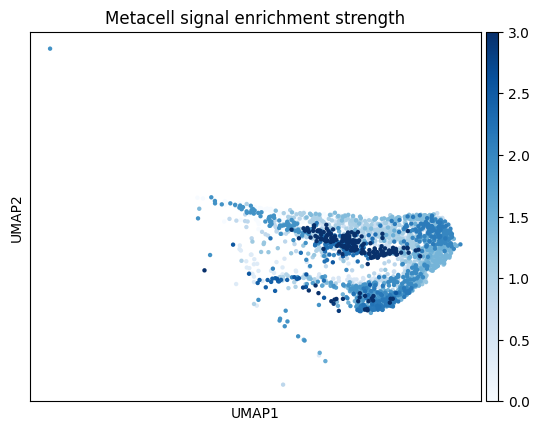

/Users/kewalinsamart/Library/Caches/pypoetry/virtualenvs/icepop--j3XYM_Z-py3.11/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


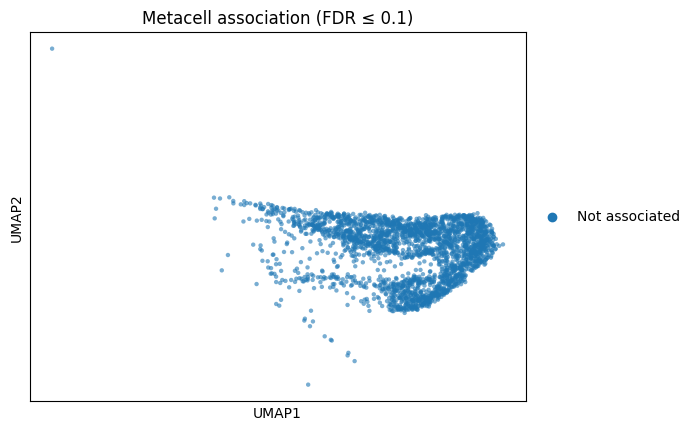

In [25]:
ct = 'enterocyte of epithelium of large intestine'

# subset cells
sub_adata = adata[adata.obs['cell_type'] == ct].copy()

# keep only relevant metacells
mc_df = mc_df.set_index('metacell')

# FDR correction
mc_fdr = pd.read_csv("../results/TM_FACS/mcfdr__trait-PASS_UC_deLange2017.csv", index_col=0)

# map metacell to q for the selected trait (ct)
mc2q = mc_fdr.loc[ct].to_dict()

sub_adata.obs['mc_z'] = sub_adata.obs['metacell'].map(mc_df['z'])
sub_adata.obs['mc_q'] = sub_adata.obs['metacell'].map(mc2q).fillna(1.0)

# mask trait-associated metacells
sub_adata.obs['mc_discovery'] = np.where(
    sub_adata.obs['mc_q'] <= 0.1,
    'Associated',
    'Not associated'
)

# plot continuous metacell signal (z-score; enrichment strength)
sc.pl.umap(
    sub_adata,
    color='mc_z',
    cmap='Blues',
    size=40,
    vmin=0,
    vmax=3,
    title='Metacell signal enrichment strength' 
)

# plot associated/not-associated metacells (binary significance based on FDR threshold: q < 0.01)
sc.pl.umap(
    sub_adata,
    color='mc_discovery',
    size=40,
    alpha=0.6,
    title='Metacell association (FDR ≤ 0.1)' 
)

## 5. Example code to check influenced genes

In [26]:
f = np.load('../results/TM_FACS/dfbs__trait-PASS_UC_deLange2017.npz', allow_pickle=True)
cg_dfbs = pd.DataFrame(f['dfbs'], index=f['celltypes'], columns=f['genes'])
cg_dfbs.head()

,148398,26155,339451,84069,84808,9636,375790,401934,54991,254173,...,440836,113730,644186,1375,1120,23542,410,85358,49,11158
B cell,-0.000703,0.000091,-0.000118,0.004541,0.000673,-0.000373,-0.002030,0.004057,-0.001981,-0.004155,...,-0.007510,-0.003172,-0.001379,-0.000026,-0.000822,0.002237,0.002959,-0.002245,0.000094,0.000638
Bergmann glial cell,-0.000207,-0.000112,-0.000032,0.002018,0.000275,-0.000142,-0.000567,0.001979,-0.001216,-0.001798,...,-0.003200,-0.001323,-0.000561,0.000049,0.000552,-0.001153,0.000159,-0.000944,0.000088,0.000269
Brush cell of epithelium proper of large intestine,-0.000133,-0.000085,-0.000029,0.000654,0.000191,-0.000070,0.000265,-0.000889,0.000864,0.007862,...,0.001299,0.034794,0.000595,0.000032,0.000172,0.000489,0.001001,-0.000511,0.000010,0.000075
"CD4-positive, alpha-beta T cell",0.000122,0.000128,-0.000084,0.004054,0.000731,0.000106,-0.001797,0.003645,-0.000191,-0.003016,...,-0.005067,-0.004864,-0.001224,0.000044,0.000238,0.001910,0.002742,-0.002019,0.000124,0.000595
"CD8-positive, alpha-beta T cell",0.000088,0.000206,-0.000069,0.003653,0.000391,0.000094,-0.001683,0.002617,-0.000125,-0.002853,...,-0.006304,-0.002632,-0.001143,0.000019,0.000198,0.001676,0.002741,-0.001869,0.000126,0.000559


In [27]:
cg_dfbs_long = cg_dfbs.reset_index().melt(
    id_vars='index',
    var_name='Entrez',
    value_name='Influence score'
)

cg_dfbs_long = cg_dfbs_long.rename(columns={'index': 'Cell type'})
cg_dfbs_long = cg_dfbs_long[cg_dfbs_long["Influence score"] != 0]

# assess assocaitions using influence score threshold calculated as
# 2/np.sqrt(n), n is number of genes included in the analysis
n = cg_dfbs.shape[1]
threshold = 2 / np.sqrt(n)

cg_dfbs_long["Associated"] = cg_dfbs_long["Influence score"].abs() > threshold

# add gene info
mg = mygene.MyGeneInfo()

gene_ids = cg_dfbs_long["Entrez"].astype(str).unique().tolist()

gene_info = mg.querymany(
    gene_ids,
    scopes="entrezgene",
    fields="symbol",
    species="human",
    as_dataframe=True
)

gene_map = gene_info[['symbol']]
gene_map.index.name = "Entrez"
gene_map = gene_map.reset_index()

cg_dfbs_long["Entrez"] = cg_dfbs_long["Entrez"].astype(str)
gene_map["Entrez"] = gene_map["Entrez"].astype(str)

cg_dfbs_final = cg_dfbs_long.merge(gene_map, on="Entrez", how="left")
cg_dfbs_final = cg_dfbs_final.rename(columns={"symbol": "Gene"})

# read in disease-cell association result
disease_cell_asso = pd.read_csv("../results/TM_FACS/celltype__trait-PASS_UC_deLange2017.csv")
# merge FDR values to the cg_dfbs table
cg_dfbs_final = cg_dfbs_final.merge(
    disease_cell_asso[["cell_type", "q"]],
    left_on="Cell type",
    right_on="cell_type",
    how="left"
)

# finalize and add influence score rank
cg_dfbs_final = cg_dfbs_final.drop(columns=["cell_type"])
cg_dfbs_final = cg_dfbs_final.rename(columns={"q": "FDR"})
cg_dfbs_final = cg_dfbs_final.sort_values(by="Influence score", ascending=False)
cg_dfbs_final['Influence score rank'] = range(1, len(cg_dfbs_final) + 1)

cg_dfbs_final = cg_dfbs_final[
    [
        "Gene",
        "Entrez",
        "Cell type",
        "FDR",
        "Associated",
        "Influence score",
        "Influence score rank",
    ]
]

cg_dfbs_final.head()

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


,Gene,Entrez,Cell type,FDR,Associated,Influence score,Influence score rank
21947,PLA2G2E,30814,kidney interstitial fibroblast,0.253904,True,1.363675,1
1380267,PNMT,5409,pulmonary interstitial fibroblast,0.690508,True,1.231090,2
609382,FAM162B,221303,pericyte cell,0.184001,True,1.202404,3
185203,TPO,7173,mucus secreting cell,0.939404,True,1.120082,4
517661,CTXN3,613212,Bergmann glial cell,0.999997,True,1.028306,5
